In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime

Importing the data

In [3]:
# Load the dataset
df = pd.read_csv('bus_eta_dataset2.csv')

# Display the first few rows of the dataset
df.head()

,timestamp,bus_id,route_id,stop_sequence,current_stop_name,next_stop_name,day_of_week,is_holiday,is_peak_hour,weather_condition,passenger_count,current_speed,traffic_condition,distance_to_next_stop,current_lat,current_lon,eta_minutes
0,2024-01-01 06:00:00,BUS_001,R001,1,UTAR bus stop,KJ370 Perumahan SG Long Seksyen 7,0,False,False,sunny,22,18.07,jam,1.44,3.041250,101.794550,4
1,2024-01-01 06:05:00,BUS_001,R001,2,KJ370 Perumahan SG Long Seksyen 7,KJ428 SMK SG Long,0,False,False,rainy,15,17.49,heavy,0.43,3.049810,101.799431,1
2,2024-01-01 06:10:00,BUS_001,R001,3,KJ428 SMK SG Long,Green Acre Condo,0,False,False,rainy,6,39.61,light,0.81,3.048151,101.804728,1
3,2024-01-01 06:17:00,BUS_001,R001,4,Green Acre Condo,SG Long Club House,0,False,False,windy,17,44.45,light,0.72,3.044084,101.804222,1
4,2024-01-01 06:23:00,BUS_001,R001,5,SG Long Club House,UTAR bus stop,0,False,False,windy,15,13.64,jam,0.84,3.041303,101.798319,3


Data Quality check 

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 timestamp                0
bus_id                   0
route_id                 0
stop_sequence            0
current_stop_name        0
next_stop_name           0
day_of_week              0
is_holiday               0
is_peak_hour             0
weather_condition        0
passenger_count          0
current_speed            0
traffic_condition        0
distance_to_next_stop    0
current_lat              0
current_lon              0
eta_minutes              0
dtype: int64


In [5]:
# Check for duplicated rows
duplicated_rows = df.duplicated().sum()
print("Number of Duplicated Rows:", duplicated_rows)

Number of Duplicated Rows: 0


In [6]:
# Explore unique values in each column
unique_values = {col: df[col].unique() for col in df.columns}
print("Unique Values:\n", unique_values)

Unique Values:
 {'timestamp': array(['2024-01-01 06:00:00', '2024-01-01 06:05:00',
       '2024-01-01 06:10:00', ..., '2025-08-09 14:07:00',
       '2025-08-09 14:12:00', '2025-08-09 14:18:00'], dtype=object), 'bus_id': array(['BUS_001', 'BUS_002', 'BUS_003', 'BUS_004', 'BUS_005'],
      dtype=object), 'route_id': array(['R001'], dtype=object), 'stop_sequence': array([1, 2, 3, 4, 5], dtype=int64), 'current_stop_name': array(['UTAR bus stop', 'KJ370 Perumahan SG Long Seksyen 7',
       'KJ428 SMK SG Long', 'Green Acre Condo', 'SG Long Club House'],
      dtype=object), 'next_stop_name': array(['KJ370 Perumahan SG Long Seksyen 7', 'KJ428 SMK SG Long',
       'Green Acre Condo', 'SG Long Club House', 'UTAR bus stop'],
      dtype=object), 'day_of_week': array([0, 1, 2, 3, 4, 5, 6], dtype=int64), 'is_holiday': array([False,  True]), 'is_peak_hour': array([False,  True]), 'weather_condition': array(['sunny', 'rainy', 'windy', 'storm', 'foggy'], dtype=object), 'passenger_count': array([22, 1

In [7]:
# Data Type Validation
print("1. Data Type Check:")
print(df.dtypes)

1. Data Type Check:
timestamp                 object
bus_id                    object
route_id                  object
stop_sequence              int64
current_stop_name         object
next_stop_name            object
day_of_week                int64
is_holiday                  bool
is_peak_hour                bool
weather_condition         object
passenger_count            int64
current_speed            float64
traffic_condition         object
distance_to_next_stop    float64
current_lat              float64
current_lon              float64
eta_minutes                int64
dtype: object


In [8]:
# Convert timestamp to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Check if numeric columns are actually numeric
numeric_cols = ['passenger_count', 'current_speed', 'distance_to_next_stop', 
                'current_lat', 'current_lon', 'eta_minutes']
for col in numeric_cols:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum()
    print(f"Non-numeric values in {col}: {non_numeric}")

Non-numeric values in passenger_count: 0
Non-numeric values in current_speed: 0
Non-numeric values in distance_to_next_stop: 0
Non-numeric values in current_lat: 0
Non-numeric values in current_lon: 0
Non-numeric values in eta_minutes: 0


In [9]:
# Range/Boundary Checks
# Check passenger counts for reasonable values
print(f"Min passenger count: {df['passenger_count'].min()}, Max: {df['passenger_count'].max()}")
# Check speed values
print(f"Min speed: {df['current_speed'].min()}, Max: {df['current_speed'].max()}")
# Check coordinates
print(f"Latitude range: {df['current_lat'].min()} to {df['current_lat'].max()}")
print(f"Longitude range: {df['current_lon'].min()} to {df['current_lon'].max()}")

Min passenger count: 1, Max: 50
Min speed: 5.0, Max: 60.0
Latitude range: 3.040747 to 3.051625
Longitude range: 101.794283 to 101.806459


In [10]:
# Consistency Checks
# Check if is_peak_hour matches typical peak hours
df['hour'] = df['timestamp'].dt.hour
peak_mismatch = df[((df['hour'] >= 7) & (df['hour'] <= 9) & (df['is_peak_hour'] == False)) | 
                   ((df['hour'] < 7) & (df['hour'] > 9) & (df['is_peak_hour'] == True))]
print(f"Potential peak hour inconsistencies: {len(peak_mismatch)}")
# Check if day_of_week is consistent with timestamp
df['actual_day'] = df['timestamp'].dt.weekday
day_mismatch = df[df['day_of_week'] != df['actual_day']]
print(f"Day of week inconsistencies: {len(day_mismatch)}")

Potential peak hour inconsistencies: 5005
Day of week inconsistencies: 0


EDA

In [11]:
# Outlier Detection
print("Outlier Detection:")
# Using IQR method for outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"Outliers in {col}: {len(outliers)}")

Outlier Detection:
Outliers in passenger_count: 3671
Outliers in current_speed: 0
Outliers in distance_to_next_stop: 40336
Outliers in current_lat: 0
Outliers in current_lon: 0
Outliers in eta_minutes: 7585


In [12]:
# Time Series Checks
print("\nTime Series Checks:")
# Check for time gaps or irregularities
df_sorted = df.sort_values(['bus_id', 'timestamp'])
df_sorted['time_diff'] = df_sorted.groupby('bus_id')['timestamp'].diff().dt.total_seconds().div(60)
print(f"Time differences statistics (minutes):")
print(df_sorted['time_diff'].describe())


Time Series Checks:
Time differences statistics (minutes):
count    99995.000000
mean        42.213581
std         96.942165
min          5.000000
25%          5.000000
50%          6.000000
75%          7.000000
max        679.000000
Name: time_diff, dtype: float64


In [13]:
# Check for chronological inconsistencies within bus routes
for bus in df['bus_id'].unique():
    bus_data = df[df['bus_id'] == bus].sort_values('timestamp')
    if not bus_data['stop_sequence'].is_monotonic_increasing:
        print(f"Non-monotonic stop sequence for {bus}")

Non-monotonic stop sequence for BUS_001
Non-monotonic stop sequence for BUS_002
Non-monotonic stop sequence for BUS_003
Non-monotonic stop sequence for BUS_004
Non-monotonic stop sequence for BUS_005


In [14]:
# Logical Relationship Validation
print("\nLogical Relationship Validation:")
# Check if eta makes sense with speed and distance
df['calculated_eta'] = (df['distance_to_next_stop'] / df['current_speed']) * 60  # minutes
large_eta_diff = df[abs(df['calculated_eta'] - df['eta_minutes']) > 2]
print(f"Potential ETA inconsistencies: {len(large_eta_diff)}")


Logical Relationship Validation:
Potential ETA inconsistencies: 2650


In [15]:
# Check if traffic condition matches speed
speed_traffic_mismatch = df[
    ((df['traffic_condition'] == 'jam') & (df['current_speed'] > 30)) |
    ((df['traffic_condition'] == 'light') & (df['current_speed'] < 10))
]
print(f"Speed-traffic condition mismatches: {len(speed_traffic_mismatch)}")

Speed-traffic condition mismatches: 3



Statistical Distribution Analysis:
                           timestamp  stop_sequence   day_of_week  \
count                         100000  100000.000000  100000.00000   
mean   2024-10-20 05:30:43.342199808       2.988910       2.99254   
min              2024-01-01 06:00:00       1.000000       0.00000   
25%              2024-05-26 13:40:30       2.000000       1.00000   
50%              2024-10-19 22:48:00       3.000000       3.00000   
75%              2025-03-15 19:26:15       4.000000       5.00000   
max              2025-08-09 14:18:00       5.000000       6.00000   
std                              NaN       1.414449       1.99766   

       passenger_count  current_speed  distance_to_next_stop    current_lat  \
count    100000.000000  100000.000000          100000.000000  100000.000000   
mean         20.480090      30.388755               0.849134       3.045919   
min           1.000000       5.000000               0.430000       3.040747   
25%          14.000000    

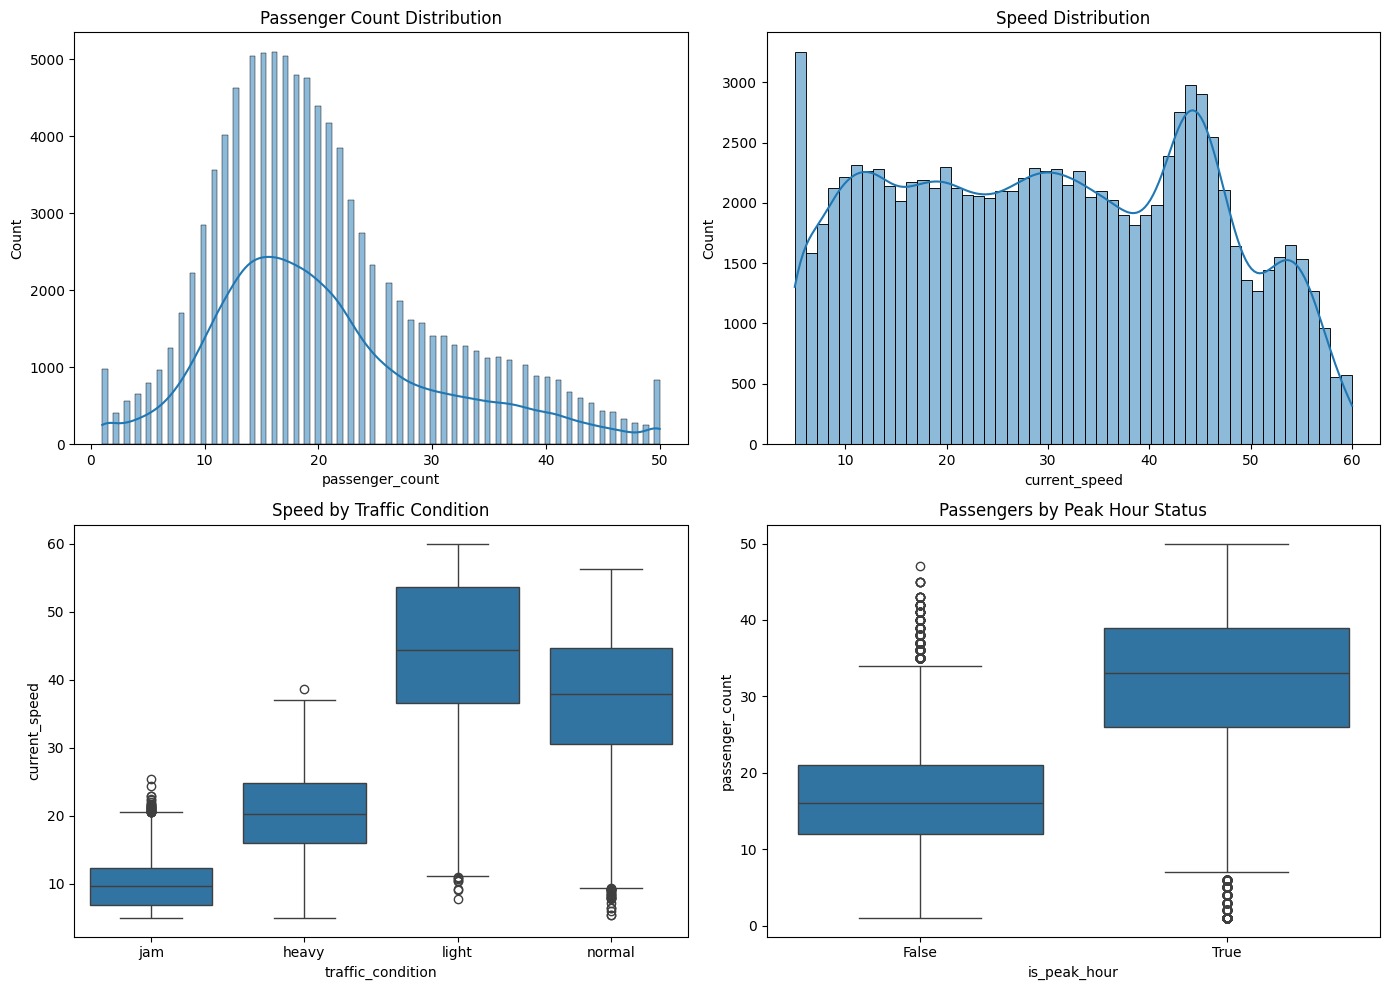

In [16]:
# Statistical Distribution Analysis
print("\nStatistical Distribution Analysis:")
print(df.describe())

# Visualize key distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['passenger_count'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Passenger Count Distribution')

sns.histplot(df['current_speed'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Speed Distribution')

sns.boxplot(x='traffic_condition', y='current_speed', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Speed by Traffic Condition')

sns.boxplot(x='is_peak_hour', y='passenger_count', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Passengers by Peak Hour Status')

plt.tight_layout()
plt.show()

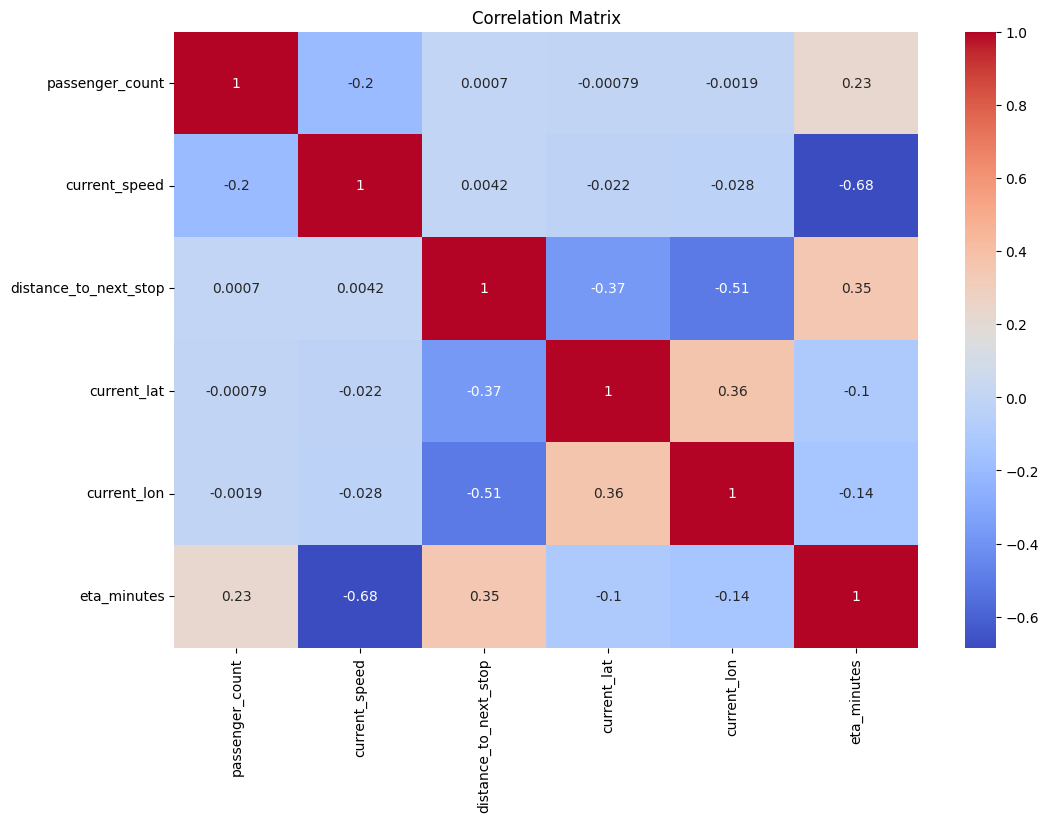

In [17]:
# Correlation matrix of numeric variables
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

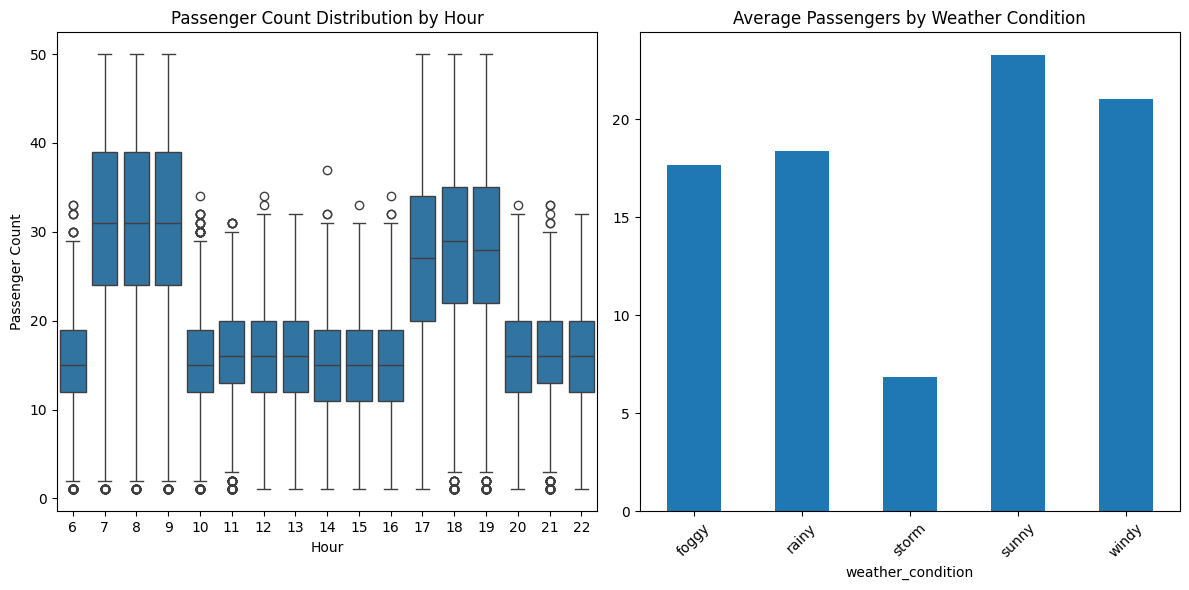

In [18]:
# Passenger analysis
plt.figure(figsize=(12, 6))
    
# Passenger count by hour
plt.subplot(1, 2, 1)
sns.boxplot(x='hour', y='passenger_count', data=df)
plt.title('Passenger Count Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Passenger Count')
    
# Average passengers by weather
plt.subplot(1, 2, 2)
df.groupby('weather_condition')['passenger_count'].mean().plot(kind='bar')
plt.title('Average Passengers by Weather Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

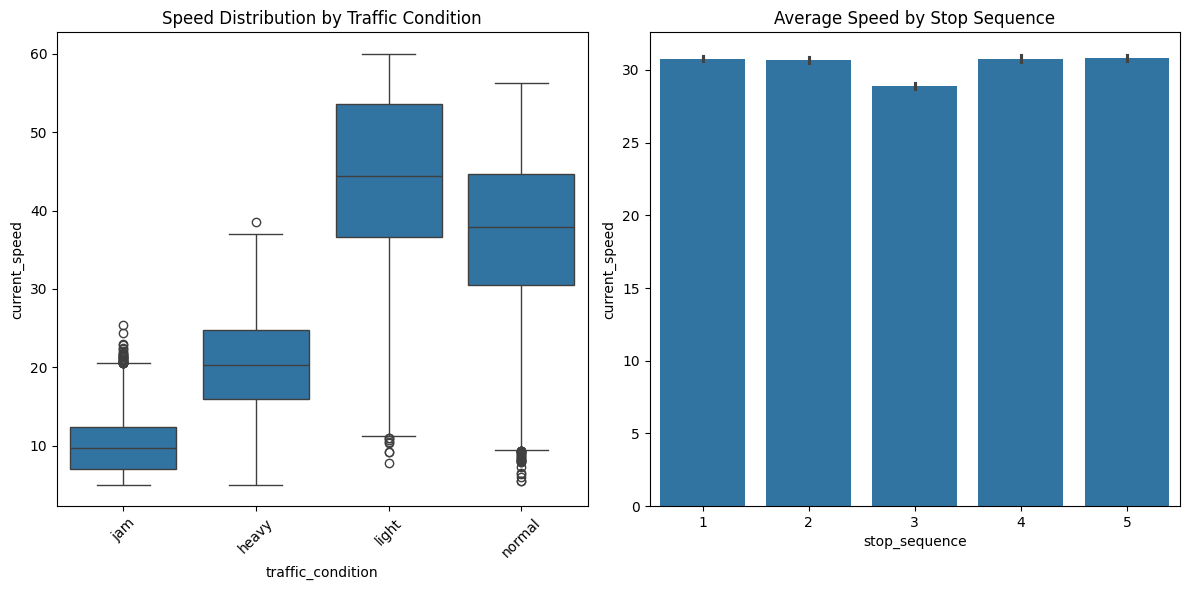

In [19]:
# Speed and traffic analysis
plt.figure(figsize=(12, 6))
    
# Speed by traffic condition
plt.subplot(1, 2, 1)
sns.boxplot(x='traffic_condition', y='current_speed', data=df)
plt.title('Speed Distribution by Traffic Condition')
plt.xticks(rotation=45)
    
# Average speed by stop sequence
plt.subplot(1, 2, 2)
sns.barplot(x='stop_sequence', y='current_speed', data=df)
plt.title('Average Speed by Stop Sequence')
plt.tight_layout()
plt.show()

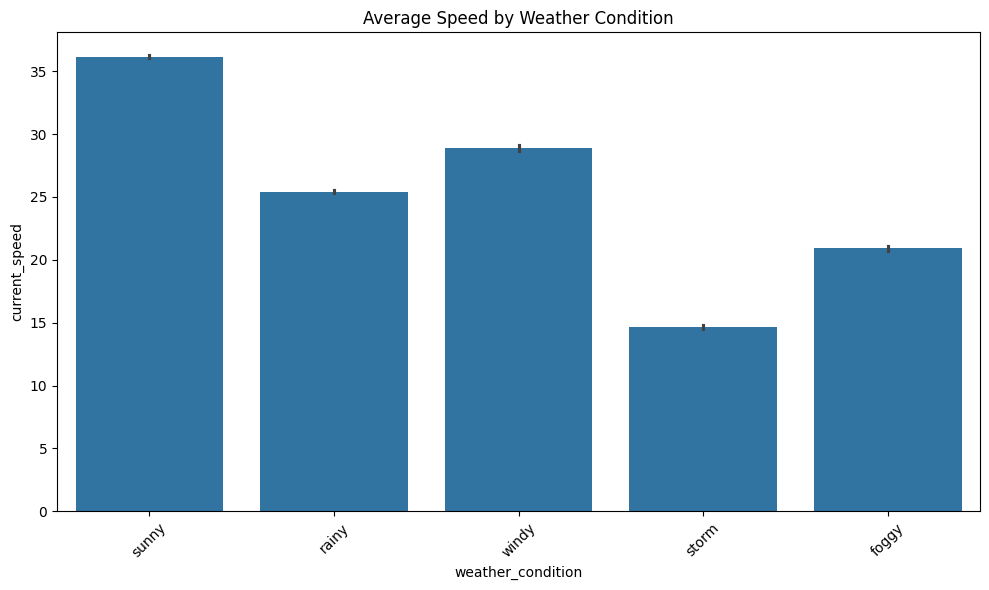

In [20]:
# Weather impact analysis
plt.figure(figsize=(10, 6))
    
# Average speed by weather
sns.barplot(x='weather_condition', y='current_speed', data=df)
plt.title('Average Speed by Weather Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Route analysis
# Calculate average time between stops
route_analysis = df.groupby('stop_sequence').agg({
    'distance_to_next_stop': 'mean',
    'eta_minutes': 'mean',
    'passenger_count': 'mean'
}).round(2)
    
print("\nRoute Analysis:")
print(route_analysis)


Route Analysis:
               distance_to_next_stop  eta_minutes  passenger_count
stop_sequence                                                     
1                               1.44         3.95            20.50
2                               0.43         0.79            20.48
3                               0.81         2.62            20.48
4                               0.72         1.72            20.50
5                               0.84         2.11            20.43


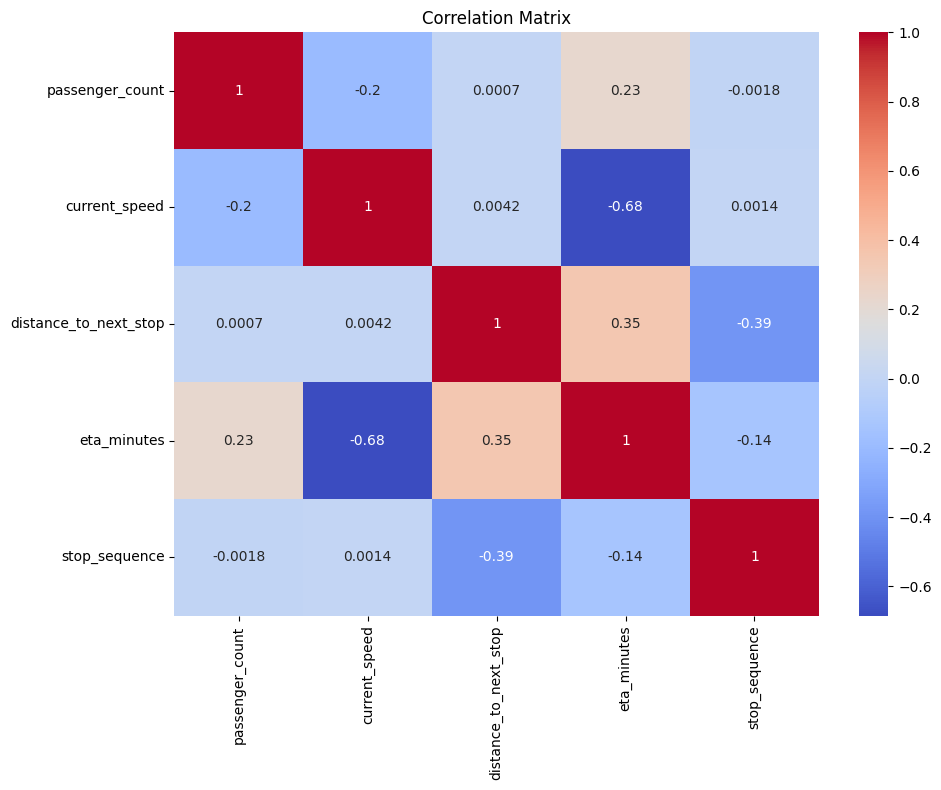

In [22]:
# Correlation analysis
# Select numerical columns
numerical_cols = ['passenger_count', 'current_speed', 'distance_to_next_stop', 
                     'eta_minutes', 'stop_sequence']
    
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

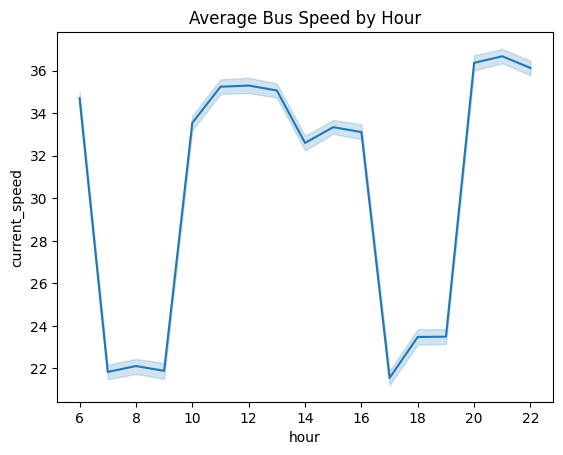

In [23]:
# Time-based trends: Bus speed over time
df['hour'] = df['timestamp'].dt.hour
sns.lineplot(x='hour', y='current_speed', data=df)
plt.title("Average Bus Speed by Hour")
plt.show()

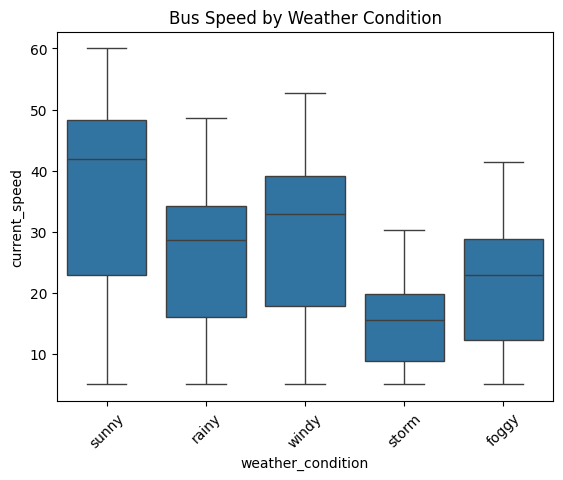

In [24]:
# Weather vs speed
sns.boxplot(x='weather_condition', y='current_speed', data=df)
plt.title("Bus Speed by Weather Condition")
plt.xticks(rotation=45)
plt.show()


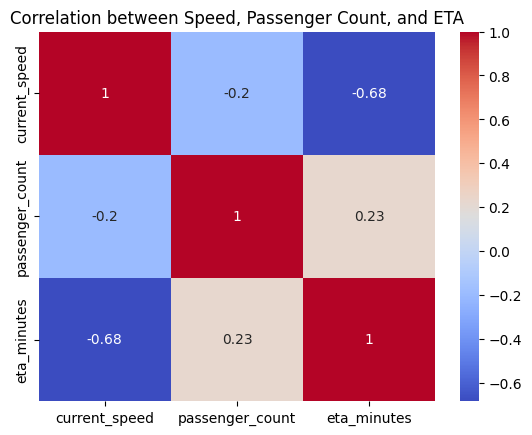

In [25]:
# Correlation heatmap
corr_matrix = df[['current_speed', 'passenger_count', 'eta_minutes']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between Speed, Passenger Count, and ETA")
plt.show()

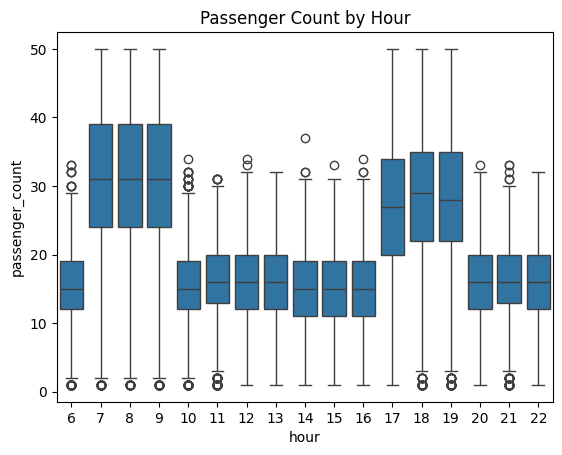

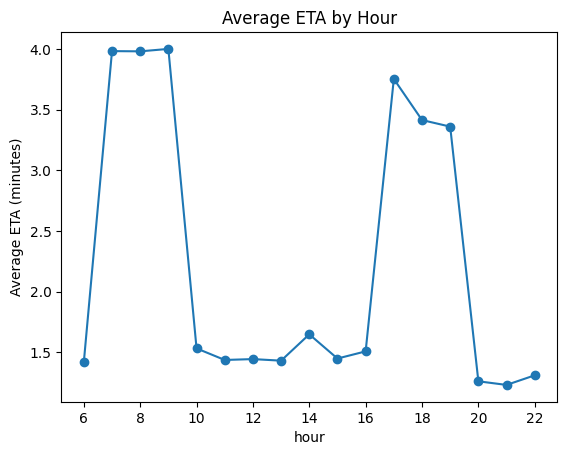

In [26]:
# Passenger count by hour
sns.boxplot(x='hour', y='passenger_count', data=df)
plt.title("Passenger Count by Hour")
plt.show()

# Average ETA by hour
avg_eta_by_hour = df.groupby('hour')['eta_minutes'].mean()
avg_eta_by_hour.plot(kind='line', marker='o', title="Average ETA by Hour")
plt.ylabel("Average ETA (minutes)")
plt.show()

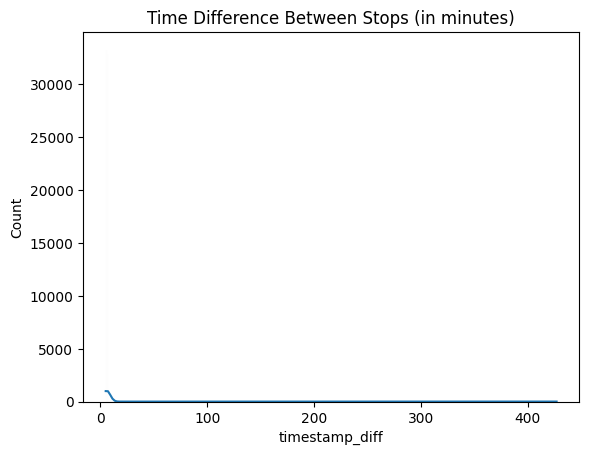

In [27]:
# Time difference between stops (in minutes)
df['timestamp_diff'] = df['timestamp'].diff().dt.total_seconds() / 60
sns.histplot(df['timestamp_diff'], kde=True)
plt.title("Time Difference Between Stops (in minutes)")
plt.show()


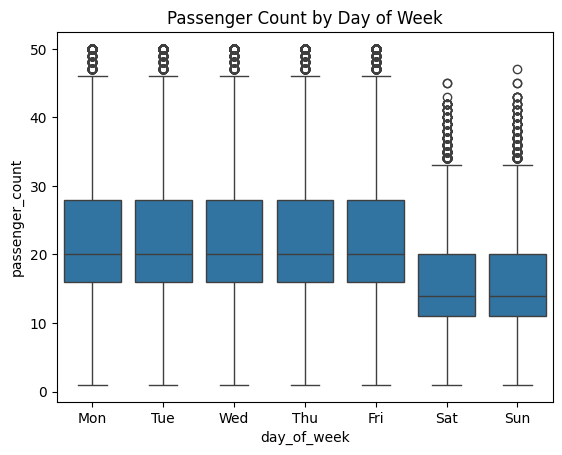

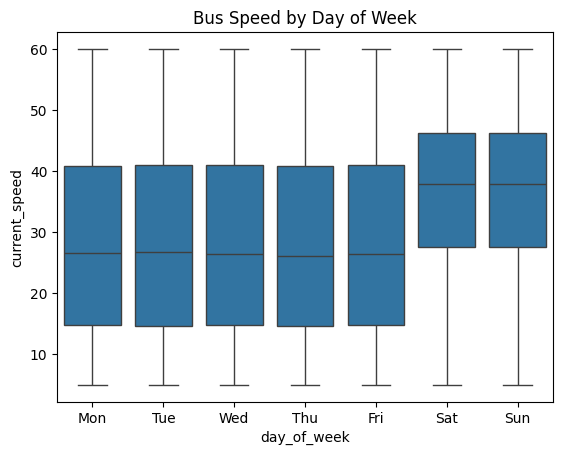

In [28]:
# Extract day of the week (0=Monday, 6=Sunday)
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Day of week vs. passenger count
sns.boxplot(x='day_of_week', y='passenger_count', data=df)
plt.title("Passenger Count by Day of Week")
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

# Day of week vs. speed
sns.boxplot(x='day_of_week', y='current_speed', data=df)
plt.title("Bus Speed by Day of Week")
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()


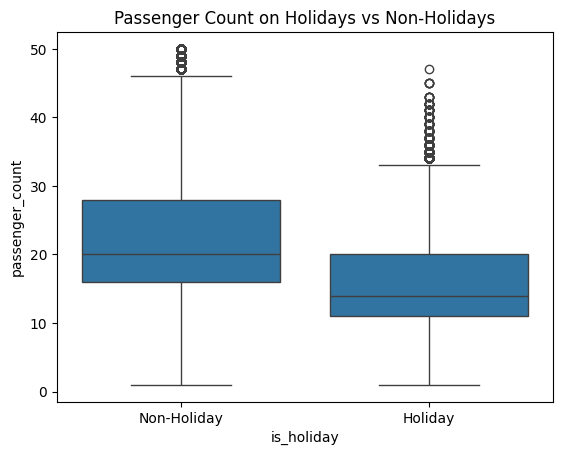

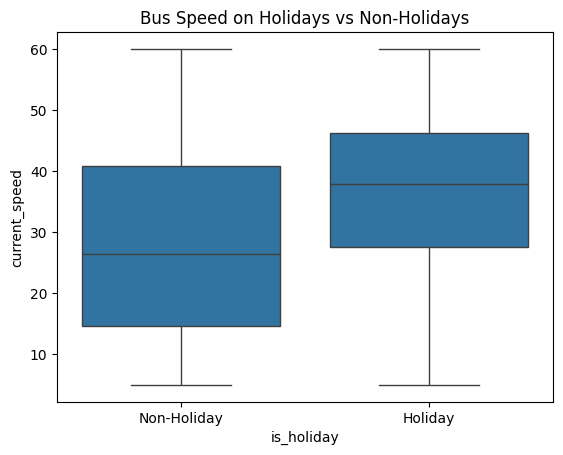

In [29]:
# Holiday vs non-holiday comparison of passenger count
sns.boxplot(x='is_holiday', y='passenger_count', data=df)
plt.title("Passenger Count on Holidays vs Non-Holidays")
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.show()

# Holiday vs non-holiday comparison of bus speed
sns.boxplot(x='is_holiday', y='current_speed', data=df)
plt.title("Bus Speed on Holidays vs Non-Holidays")
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.show()


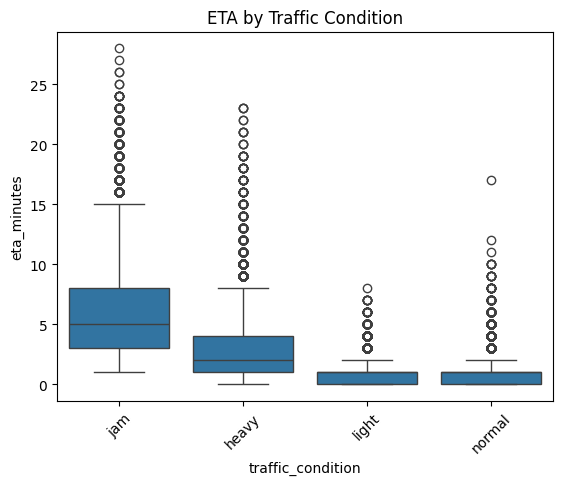

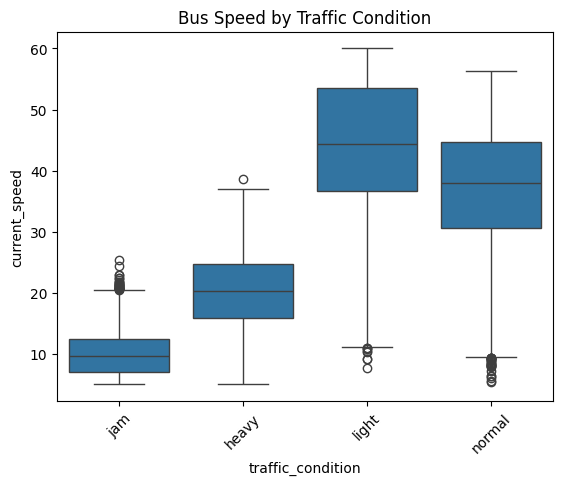

In [30]:
# Traffic condition vs. ETA
sns.boxplot(x='traffic_condition', y='eta_minutes', data=df)
plt.title("ETA by Traffic Condition")
plt.xticks(rotation=45)
plt.show()

# Traffic condition vs. bus speed
sns.boxplot(x='traffic_condition', y='current_speed', data=df)
plt.title("Bus Speed by Traffic Condition")
plt.xticks(rotation=45)
plt.show()

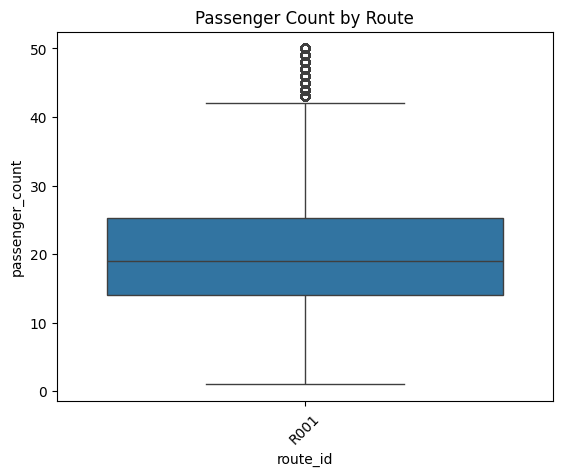

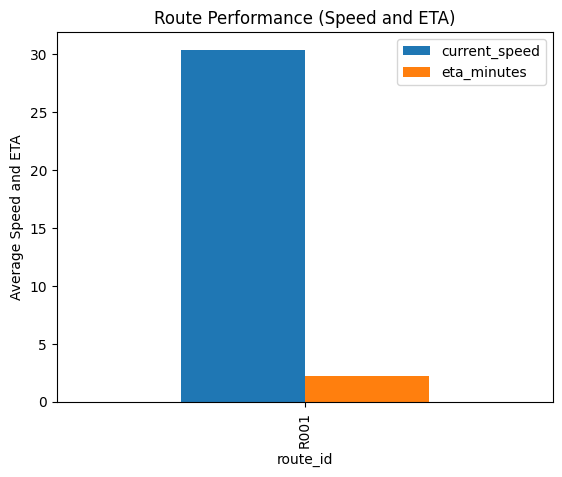

In [31]:
# Route vs. passenger count
sns.boxplot(x='route_id', y='passenger_count', data=df)
plt.title("Passenger Count by Route")
plt.xticks(rotation=45)
plt.show()

# Average speed and ETA by route
route_performance = df.groupby('route_id')[['current_speed', 'eta_minutes']].mean()
route_performance.plot(kind='bar', title="Route Performance (Speed and ETA)")
plt.ylabel("Average Speed and ETA")
plt.show()


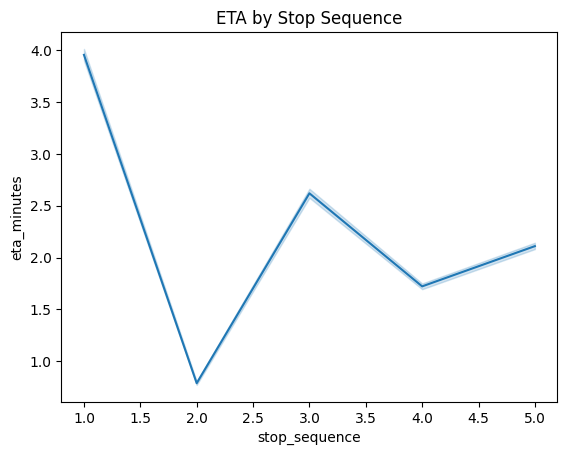

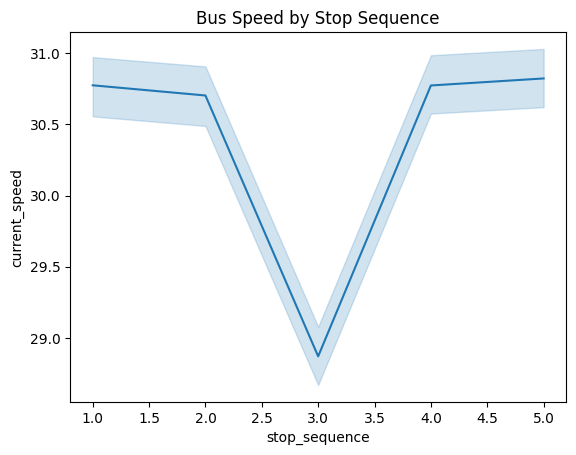

In [32]:
# Stop sequence vs. ETA
sns.lineplot(x='stop_sequence', y='eta_minutes', data=df)
plt.title("ETA by Stop Sequence")
plt.show()

# Stop sequence vs. bus speed
sns.lineplot(x='stop_sequence', y='current_speed', data=df)
plt.title("Bus Speed by Stop Sequence")
plt.show()

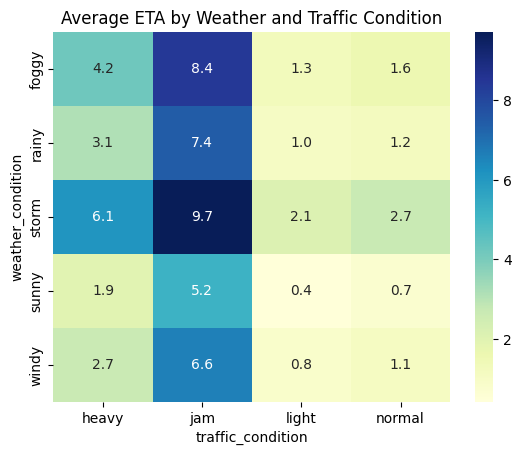

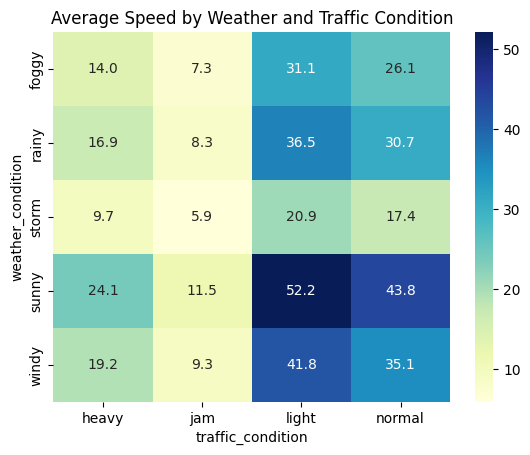

In [33]:
# Weather and traffic condition vs. ETA
weather_traffic_eta = df.groupby(['weather_condition', 'traffic_condition'])['eta_minutes'].mean().unstack()
sns.heatmap(weather_traffic_eta, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title("Average ETA by Weather and Traffic Condition")
plt.show()

# Weather and traffic condition vs. Speed
weather_traffic_speed = df.groupby(['weather_condition', 'traffic_condition'])['current_speed'].mean().unstack()
sns.heatmap(weather_traffic_speed, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title("Average Speed by Weather and Traffic Condition")
plt.show()

In [34]:
# Check for categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category', 'string']).columns
print("Categorical Columns:", categorical_columns)

Categorical Columns: Index(['bus_id', 'route_id', 'current_stop_name', 'next_stop_name',
       'weather_condition', 'traffic_condition'],
      dtype='object')


In [35]:
for col in categorical_columns:
    print(f"Column: {col}")
    print("Unique Values:", df[col].unique())
    print("Value Counts:\n", df[col].value_counts())
    print("-" * 30)

Column: bus_id
Unique Values: ['BUS_001' 'BUS_002' 'BUS_003' 'BUS_004' 'BUS_005']
Value Counts:
 bus_id
BUS_001    20531
BUS_002    20528
BUS_003    20525
BUS_004    20252
BUS_005    18164
Name: count, dtype: int64
------------------------------
Column: route_id
Unique Values: ['R001']
Value Counts:
 route_id
R001    100000
Name: count, dtype: int64
------------------------------
Column: current_stop_name
Unique Values: ['UTAR bus stop' 'KJ370 Perumahan SG Long Seksyen 7' 'KJ428 SMK SG Long'
 'Green Acre Condo' 'SG Long Club House']
Value Counts:
 current_stop_name
UTAR bus stop                        20235
KJ370 Perumahan SG Long Seksyen 7    20101
KJ428 SMK SG Long                    19989
Green Acre Condo                     19888
SG Long Club House                   19787
Name: count, dtype: int64
------------------------------
Column: next_stop_name
Unique Values: ['KJ370 Perumahan SG Long Seksyen 7' 'KJ428 SMK SG Long'
 'Green Acre Condo' 'SG Long Club House' 'UTAR bus stop']
Val

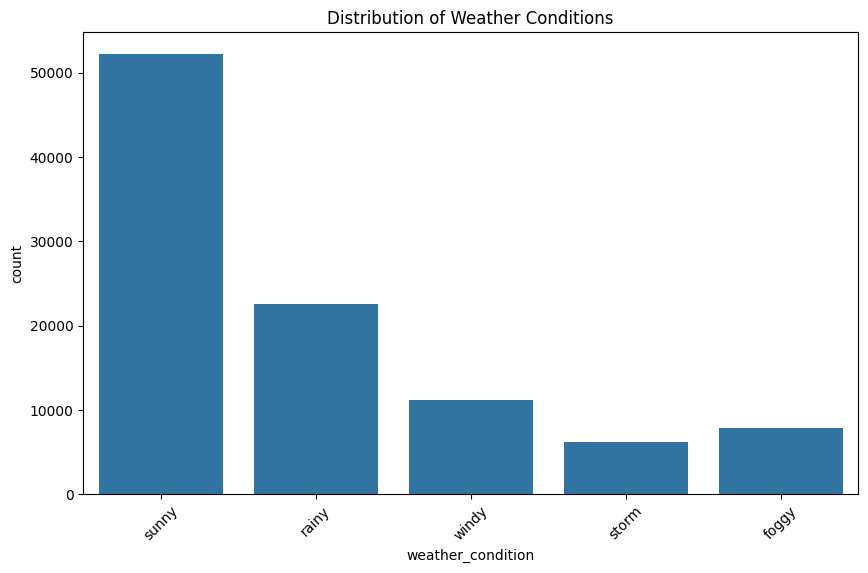

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='weather_condition')  # Replace with your column
plt.title("Distribution of Weather Conditions")
plt.xticks(rotation=45)
plt.show()


In [37]:
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [38]:
df.shape

(100000, 21)

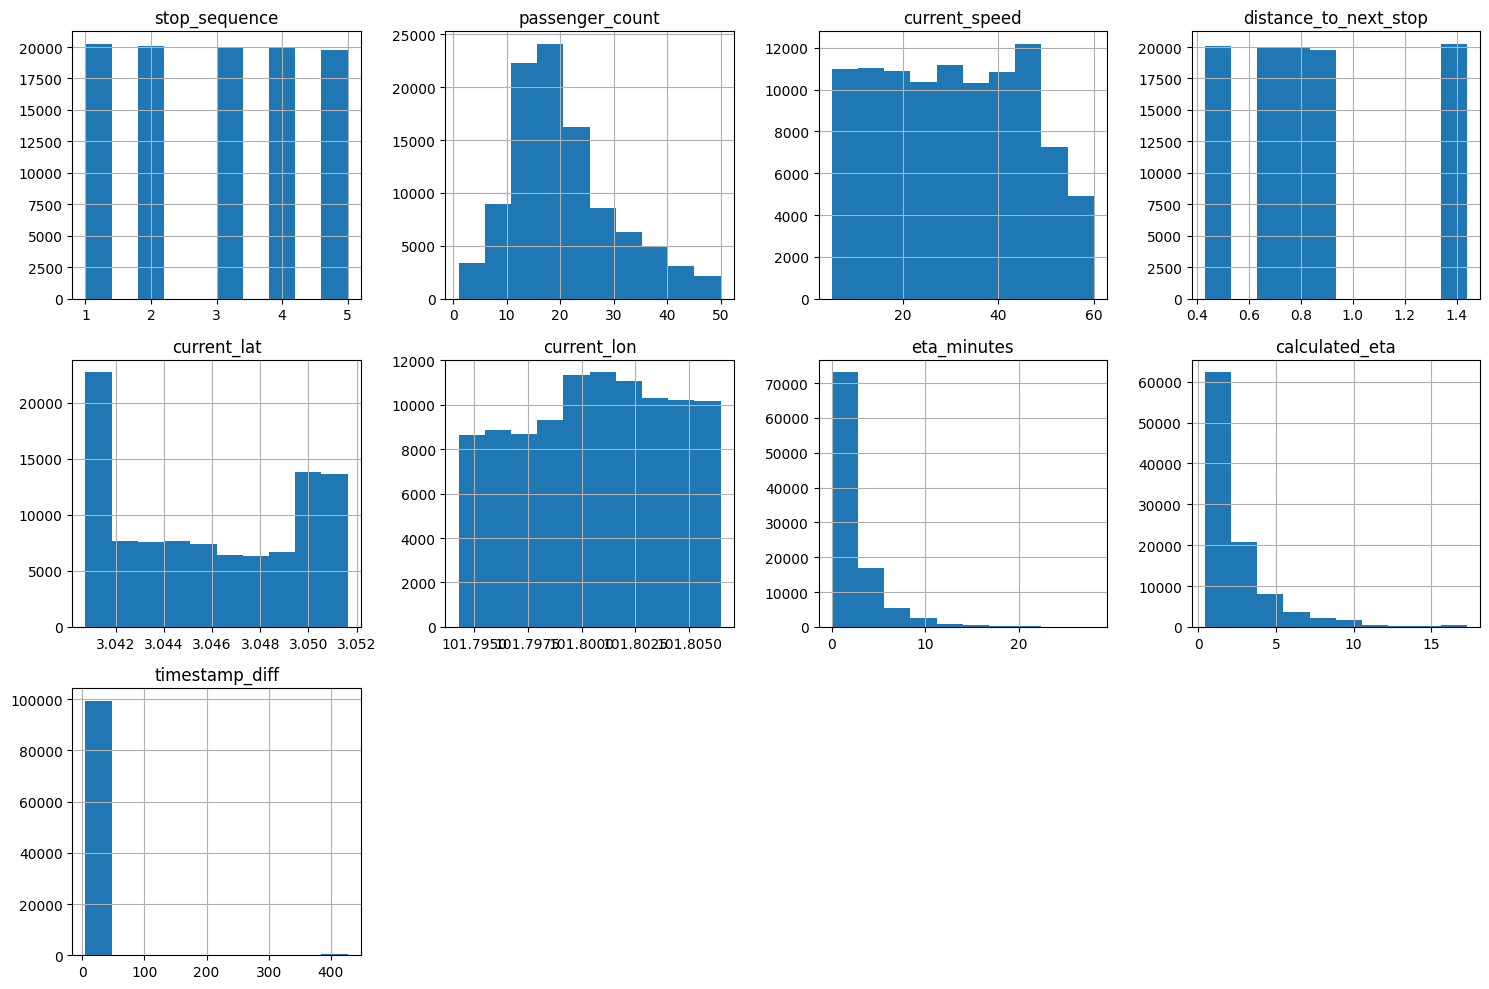

In [39]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i+1)
    df[col].hist()
    plt.title(col)
plt.tight_layout()
plt.show() 

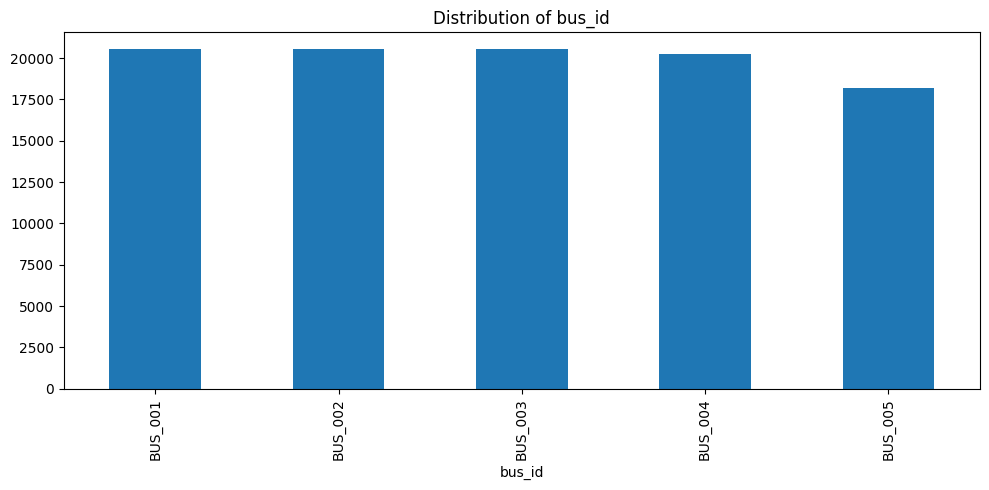

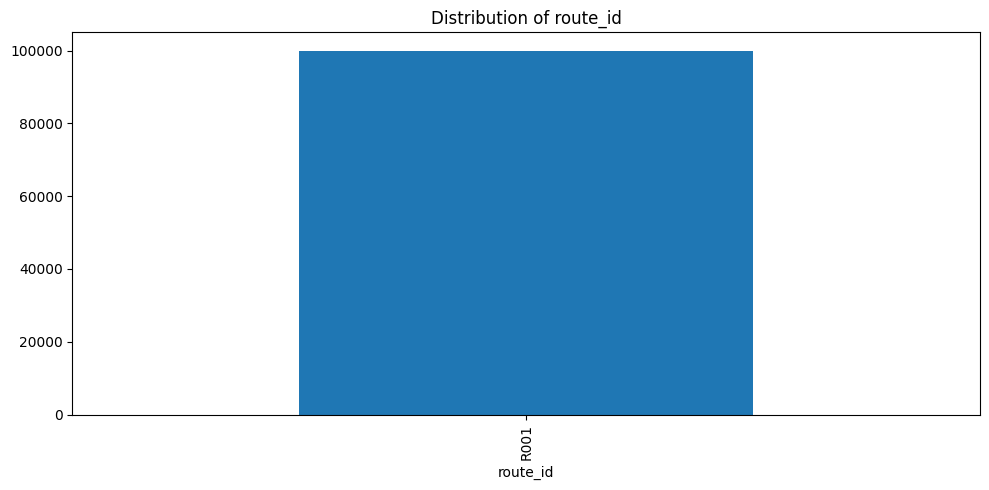

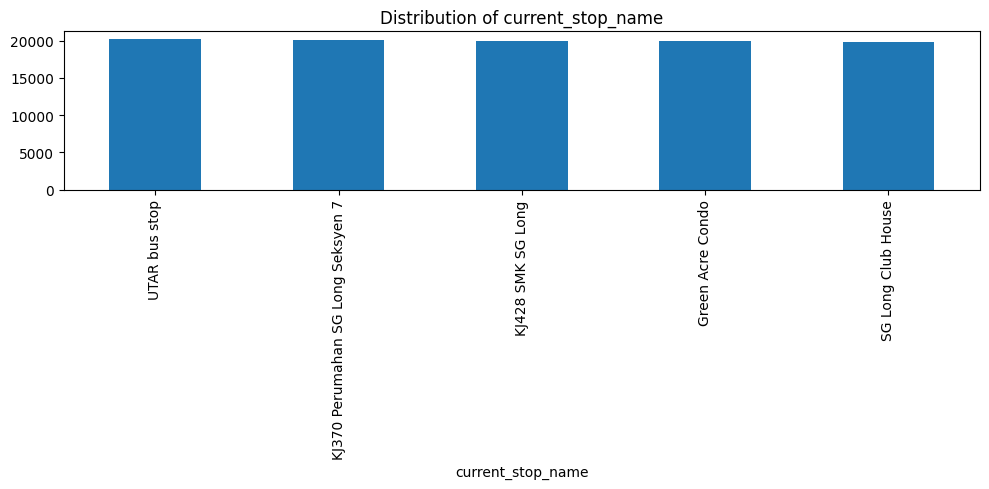

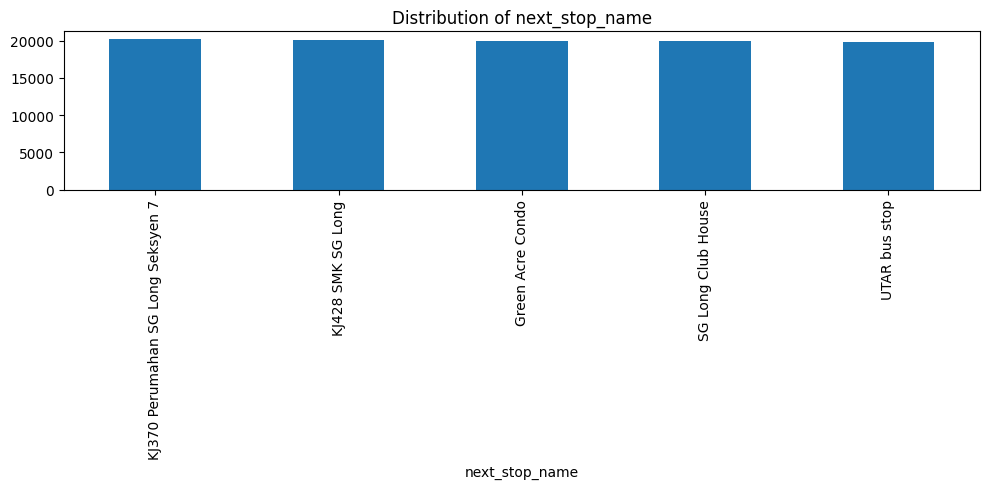

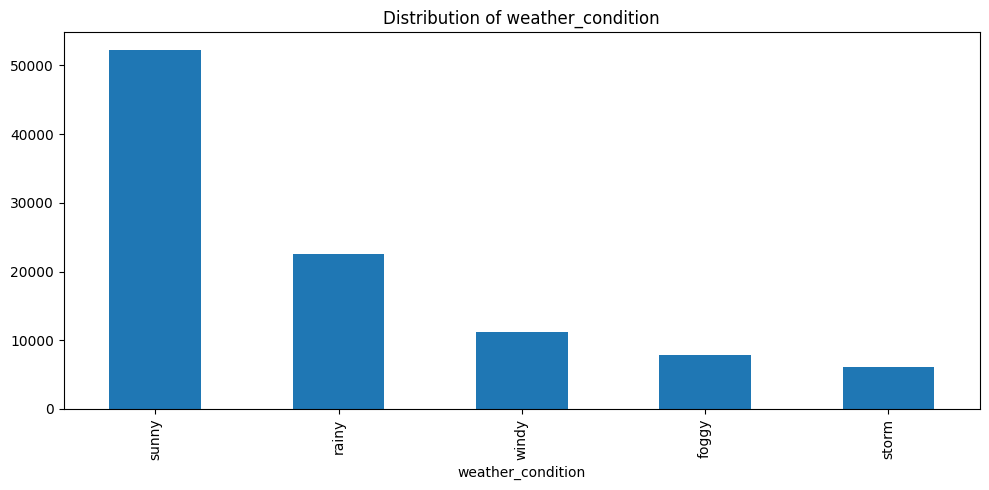

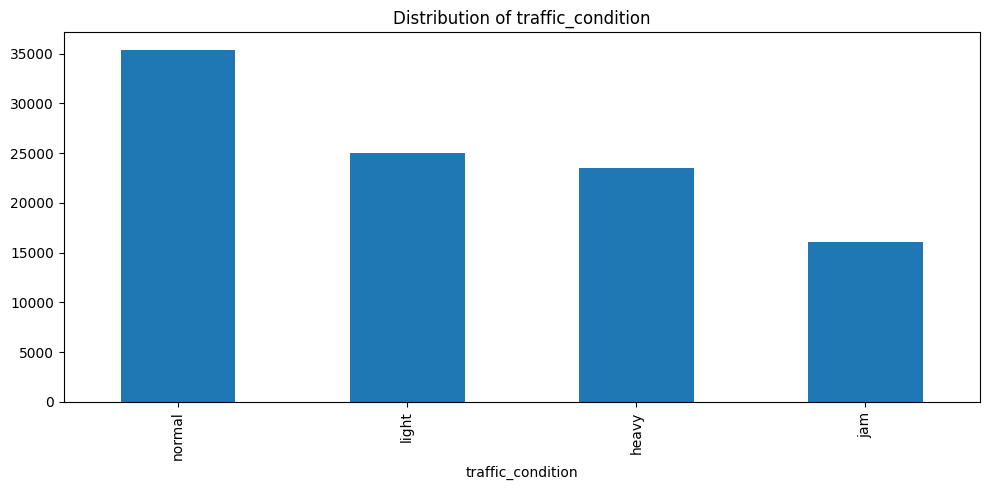

In [40]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()  # Add this line to display the figure

In [41]:
df_categorical = pd.DataFrame(df)

# Drop route_id as it has only one unique value
df_categorical.drop(columns=['route_id'], inplace=True)

# Label Encoding for current_stop_name and next_stop_name
label_encoder = LabelEncoder()
df_categorical['current_stop_name'] = label_encoder.fit_transform(df_categorical['current_stop_name'])
df_categorical['next_stop_name'] = label_encoder.fit_transform(df_categorical['next_stop_name'])

# Ordinal Encoding for weather_condition
weather_mapping = {'sunny': 0, 'rainy': 1, 'windy': 2, 'storm': 3, 'foggy': 4}
df_categorical['weather_condition'] = df_categorical['weather_condition'].map(weather_mapping)

# Ordinal Encoding for traffic_condition
traffic_mapping = {'jam': 0, 'heavy': 1, 'light': 2, 'normal': 3}
df_categorical['traffic_condition'] = df_categorical['traffic_condition'].map(traffic_mapping)

# Display the transformed DataFrame
print(df_categorical.head(5))

            timestamp   bus_id  stop_sequence  current_stop_name  \
0 2024-01-01 06:00:00  BUS_001              1                  4   
1 2024-01-01 06:05:00  BUS_001              2                  1   
2 2024-01-01 06:10:00  BUS_001              3                  2   
3 2024-01-01 06:17:00  BUS_001              4                  0   
4 2024-01-01 06:23:00  BUS_001              5                  3   

   next_stop_name  day_of_week  is_holiday  is_peak_hour  weather_condition  \
0               1            0       False         False                  0   
1               2            0       False         False                  1   
2               0            0       False         False                  1   
3               3            0       False         False                  2   
4               4            0       False         False                  2   

   passenger_count  current_speed  traffic_condition  distance_to_next_stop  \
0               22          18.07    

In [42]:
selected_columns = [  
    'timestamp', 'stop_sequence', 'current_stop_name', 'next_stop_name','day_of_week',  
    'is_holiday', 'is_peak_hour', 'weather_condition','passenger_count',  
    'current_speed', 'distance_to_next_stop',  
    'current_lat', 'current_lon', 'eta_minutes'  
]  # 'bus_id

# Extract the required data  
df_selected = df_categorical[selected_columns]  

# Save to CSV  
df_selected.to_csv('preprocessed.csv', index=False)  
df_selected.shape

(100000, 14)

In [43]:
# Scaling
import joblib
df_scale = pd.read_csv("preprocessed.csv")
columns_to_scale = ["current_speed", "distance_to_next_stop", "eta_minutes", "passenger_count"]

# Apply Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax_scaled = df_scale.copy()
df_minmax_scaled[columns_to_scale] = minmax_scaler.fit_transform(df_scale[columns_to_scale])

# Apply Standard Scaling (Z-score normalization)
standard_scaler = StandardScaler()
df_standard_scaled = df_scale.copy()
df_standard_scaled[columns_to_scale] = standard_scaler.fit_transform(df_scale[columns_to_scale])

print("\nMin-Max Scaled Data Sample:\n", df_minmax_scaled[columns_to_scale].head())
print("\nStandard Scaled Data Sample:\n", df_standard_scaled[columns_to_scale].head())

# Save the scalers for later use
joblib.dump(minmax_scaler, 'minmax_scaler.joblib')
joblib.dump(standard_scaler, 'standard_scaler.joblib')

# Create specific scalers for each column if needed (especially for target variable)
# This allows more precise inverse transformation later
eta_minmax_scaler = MinMaxScaler()
eta_minmax_scaler.fit(df_scale[['eta_minutes']])
joblib.dump(eta_minmax_scaler, 'eta_minmax_scaler.joblib')

eta_standard_scaler = StandardScaler()
eta_standard_scaler.fit(df_scale[['eta_minutes']])
joblib.dump(eta_standard_scaler, 'eta_standard_scaler.joblib')

df_minmax_scaled.to_csv("bus_eta_minmax_scaled.csv", index=False)
df_standard_scaled.to_csv("bus_eta_standard_scaled.csv", index=False)


Min-Max Scaled Data Sample:
    current_speed  distance_to_next_stop  eta_minutes  passenger_count
0       0.237636               1.000000     0.142857         0.428571
1       0.227091               0.000000     0.035714         0.285714
2       0.629273               0.376238     0.035714         0.102041
3       0.717273               0.287129     0.035714         0.326531
4       0.157091               0.405941     0.107143         0.285714

Standard Scaled Data Sample:
    current_speed  distance_to_next_stop  eta_minutes  passenger_count
0      -0.825070               1.784809     0.608215         0.151772
1      -0.863916              -1.266062    -0.429789        -0.547219
2       0.617609              -0.118209    -0.429789        -1.445922
3       0.941776              -0.390069    -0.429789        -0.347507
4      -1.121777              -0.027590     0.262214        -0.547219
